# Figuring out what's wrong with HRDPS 1km results

## Weights file unreliable

Actually, some `NEMO` grid points require the same `HRDPS 1km` grid points to interpolate, which is quite abnormal.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd


# ============================================================
# Weight files
# ============================================================

path_weights_casr = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Data_weights/weights-HRDPS-1km_202108.nc'
)

path_weights_hrdps = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Data_weights/weights-continental2.5-hrdps.nc'
)

ds_weights_casr = xr.open_dataset(path_weights_casr)
ds_weights_hrdps = xr.open_dataset(path_weights_hrdps)


# ============================================================
# Stations
# ============================================================

stations = {
    'Pam Rocks': {
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    'Sand Heads': {
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
}


# ============================================================
# Function
# ============================================================

def get_source_and_neighbors(weights, y, x, station_name=None):
    """
    For one NEMO target grid point:

    1. Find the 4 atmospheric source points actually used
       by src01..src04 / wgt01..wgt04.

    2. For each of those 4 source points, find its 8 neighboring
       atmospheric grid points.

    3. Remove duplicates.

    Returns
    -------
    df : pandas.DataFrame

        Columns include:
            point_type
            source_number
            atmos_ilat
            atmos_ilon
            atmos_lat
            atmos_lon
            src
            weight
    """

    nlat = weights.sizes["lat"]
    nlon = weights.sizes["lon"]

    # --------------------------------------------------------
    # Step 1: get the 4 source points actually used by NEMO
    # --------------------------------------------------------

    used_points = {}

    for k in range(1, 5):

        src = int(
            weights[f"src0{k}"]
            .isel(y=y, x=x)
            .item()
        )

        weight = float(
            weights[f"wgt0{k}"]
            .isel(y=y, x=x)
            .item()
        )

        # Fortran 1-based -> Python 0-based
        idx = src - 1

        ilat = idx // nlon
        ilon = idx % nlon

        lat = float(
            weights["nav_lat"]
            .isel(lat=ilat, lon=ilon)
            .item()
        )

        lon = float(
            weights["nav_lon"]
            .isel(lat=ilat, lon=ilon)
            .item()
        )

        used_points[(ilat, ilon)] = {
            "station": station_name,
            "nemo_y": y,
            "nemo_x": x,

            "point_type": "used",
            "source_number": k,

            "src": src,
            "atmos_ilat": ilat,
            "atmos_ilon": ilon,

            "atmos_lat": lat,
            "atmos_lon": lon,

            "weight": weight,
        }


    # --------------------------------------------------------
    # Step 2: find 8 neighbors around EACH used source point
    # --------------------------------------------------------

    neighbor_points = {}

    # 8-connected neighborhood
    offsets = [
        (-1, -1),
        (-1,  0),
        (-1, +1),

        ( 0, -1),
        ( 0, +1),

        (+1, -1),
        (+1,  0),
        (+1, +1),
    ]

    for (ilat0, ilon0), source_info in used_points.items():

        source_number = source_info["source_number"]

        for dy, dx in offsets:

            ilat = ilat0 + dy
            ilon = ilon0 + dx

            # -----------------------------------------------
            # Skip points outside atmospheric grid
            # -----------------------------------------------

            if not (0 <= ilat < nlat):
                continue

            if not (0 <= ilon < nlon):
                continue


            # -----------------------------------------------
            # If this neighbor itself is one of the 4 used
            # points, don't add it as a neighbor
            # -----------------------------------------------

            if (ilat, ilon) in used_points:
                continue


            # -----------------------------------------------
            # Atmospheric coordinates
            # -----------------------------------------------

            lat = float(
                weights["nav_lat"]
                .isel(lat=ilat, lon=ilon)
                .item()
            )

            lon = float(
                weights["nav_lon"]
                .isel(lat=ilat, lon=ilon)
                .item()
            )


            # Python grid index -> Fortran linear index
            src = ilat * nlon + ilon + 1


            # -----------------------------------------------
            # Avoid duplicates
            #
            # The same neighbor may be adjacent to two or
            # more of the 4 interpolation points.
            # -----------------------------------------------

            key = (ilat, ilon)

            if key not in neighbor_points:

                neighbor_points[key] = {
                    "station": station_name,
                    "nemo_y": y,
                    "nemo_x": x,

                    "point_type": "neighbor",

                    # not one of src01..04
                    "source_number": np.nan,

                    "src": src,

                    "atmos_ilat": ilat,
                    "atmos_ilon": ilon,

                    "atmos_lat": lat,
                    "atmos_lon": lon,

                    # neighbor does NOT participate
                    # in the interpolation
                    "weight": np.nan,

                    # useful to know which used point
                    # introduced this neighbor
                    "neighbor_of": [source_number],
                }

            else:

                # This neighbor touches more than one
                # of the four source points
                neighbor_points[key]["neighbor_of"].append(
                    source_number
                )


    # --------------------------------------------------------
    # Combine
    # --------------------------------------------------------

    records = (
        list(used_points.values())
        + list(neighbor_points.values())
    )

    df = pd.DataFrame(records)

    # Sort: used points first, then atmospheric grid location
    df["_sort_type"] = df["point_type"].map({
        "used": 0,
        "neighbor": 1,
    })

    df = (
        df
        .sort_values(
            ["_sort_type", "atmos_ilat", "atmos_ilon"]
        )
        .drop(columns="_sort_type")
        .reset_index(drop=True)
    )

    return df


# ============================================================
# Pretty print
# ============================================================

def print_source_and_neighbors(weights, y, x, station_name=None):

    df = get_source_and_neighbors(
        weights,
        y=y,
        x=x,
        station_name=station_name,
    )

    used = df[df["point_type"] == "used"]
    neighbors = df[df["point_type"] == "neighbor"]

    print()
    print("=" * 100)
    print(f"{station_name}")
    print(f"NEMO target: y={y}, x={x}")
    print("=" * 100)

    print()
    print("********** 4 atmospheric points actually USED **********")
    print()

    for _, row in used.iterrows():

        print(
            f"source {int(row['source_number'])}: "
            f"(ilat, ilon)=({int(row['atmos_ilat']):4d}, "
            f"{int(row['atmos_ilon']):4d})   "
            f"lat={row['atmos_lat']:10.6f}   "
            f"lon={row['atmos_lon']:11.6f}   "
            f"weight={row['weight']:.10f}"
        )

    print()
    print(
        "********** Neighboring atmospheric grid points "
        "(deduplicated) **********"
    )
    print()

    for _, row in neighbors.iterrows():

        print(
            f"(ilat, ilon)=({int(row['atmos_ilat']):4d}, "
            f"{int(row['atmos_ilon']):4d})   "
            f"lat={row['atmos_lat']:10.6f}   "
            f"lon={row['atmos_lon']:11.6f}   "
            f"neighbor_of={row['neighbor_of']}"
        )

    print()
    print("-" * 100)
    print(f"Number of USED points     = {len(used)}")
    print(f"Number of unique neighbors = {len(neighbors)}")
    print(f"Total plotted points       = {len(df)}")

    print(
        f"Sum of interpolation weights = "
        f"{used['weight'].sum():.12f}"
    )

    print()

    return df

In [2]:
# ============================================================
# CaSR
# ============================================================

print("\n######################## HRDPS 1km ########################")

casr_results = {}

for station_name, station in stations.items():

    casr_results[station_name] = print_source_and_neighbors(
        ds_weights_casr,
        y=station["y"],
        x=station["x"],
        station_name=station_name,
    )


# ============================================================
# HRDPS
# ============================================================

print("\n######################## HRDPS 2.5km ########################")

hrdps_results = {}

for station_name, station in stations.items():

    hrdps_results[station_name] = print_source_and_neighbors(
        ds_weights_hrdps,
        y=station["y"],
        x=station["x"],
        station_name=station_name,
    )


######################## HRDPS 1km ########################

Pam Rocks
NEMO target: y=502, x=341

********** 4 atmospheric points actually USED **********

source 4: (ilat, ilon)=(  -1, 1329)   lat= 60.295024   lon= 245.550000   weight=0.0000000000

********** Neighboring atmospheric grid points (deduplicated) **********

(ilat, ilon)=(   0, 1328)   lat= 50.064856   lon= 250.453856   neighbor_of=[4]
(ilat, ilon)=(   0, 1329)   lat= 50.066924   lon= 250.467424   neighbor_of=[4]

----------------------------------------------------------------------------------------------------
Number of USED points     = 1
Number of unique neighbors = 2
Total plotted points       = 3
Sum of interpolation weights = 0.000000000000


Sand Heads
NEMO target: y=428, x=293

********** 4 atmospheric points actually USED **********

source 4: (ilat, ilon)=(  -1, 1329)   lat= 60.295024   lon= 245.550000   weight=0.0000000000

********** Neighboring atmospheric grid points (deduplicated) **********

(ilat, ilon

**Something is seriously wrong with HRDPS 1km forcing field.** Maybe it's because they do not match at all.

## HRDPS 1km and NEMO grid 

In [1]:
path_HRDPS='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_Conversion/Data_HRDPS_1km_conversion/HRDPS_1km_y2023m03d01.nc'

path_NEMO='/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/SalishSea_1d_20230301_20230331_grid_T.nc'

import xarray as xr

ds_HRDPS=xr.open_dataset(path_HRDPS)

ds_NEMO=xr.open_dataset(path_NEMO)



### HRDPS and NEMO information

In [2]:
print(ds_HRDPS)

<xarray.Dataset> Size: 1GB
Dimensions:       (time_counter: 24, y: 1180, x: 1330)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 192B 2023-03-01 ... 2023-03-0...
  * y             (y) int32 5kB 0 1 2 3 4 5 6 ... 1174 1175 1176 1177 1178 1179
  * x             (x) int32 5kB 0 1 2 3 4 5 6 ... 1324 1325 1326 1327 1328 1329
    nav_lat       (y, x) float64 13MB ...
    nav_lon       (y, x) float64 13MB ...
Data variables:
    solar         (time_counter, y, x) float32 151MB ...
    precip        (time_counter, y, x) float32 151MB ...
    therm_rad     (time_counter, y, x) float32 151MB ...
    tair          (time_counter, y, x) float32 151MB ...
    qair          (time_counter, y, x) float32 151MB ...
    u_wind        (time_counter, y, x) float32 151MB ...
    v_wind        (time_counter, y, x) float32 151MB ...
    atmpres       (time_counter, y, x) float32 151MB ...
    percentcloud  (time_counter, y, x) float32 151MB ...
Attributes: (12/16)
    title:                     

In [3]:
print(ds_NEMO)

<xarray.Dataset> Size: 7GB
Dimensions:               (y: 898, x: 398, nvertex: 4, deptht: 40,
                           axis_nbounds: 2, time_counter: 31)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
  * deptht                (deptht) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
    time_centered         (time_counter) datetime64[ns] 248B ...
  * time_counter          (time_counter) datetime64[ns] 248B 2023-03-01T12:00...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    deptht_bounds         (deptht, axis_nbounds) float32 320B ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 496B ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 496B ...
    sossheig              (time_counter, y, x)

### Visualize

Skip every 5 points in `NEMO` and 20 points in `HRDPS 1km`.

HRDPS grid shape: (1180, 1330)
NEMO  grid shape: (898, 398)
HRDPS lon/lat range: 225.370032 250.467424 45.932892 60.295024
NEMO lon/lat range: -126.19469 -1.0 -1.0 50.981987


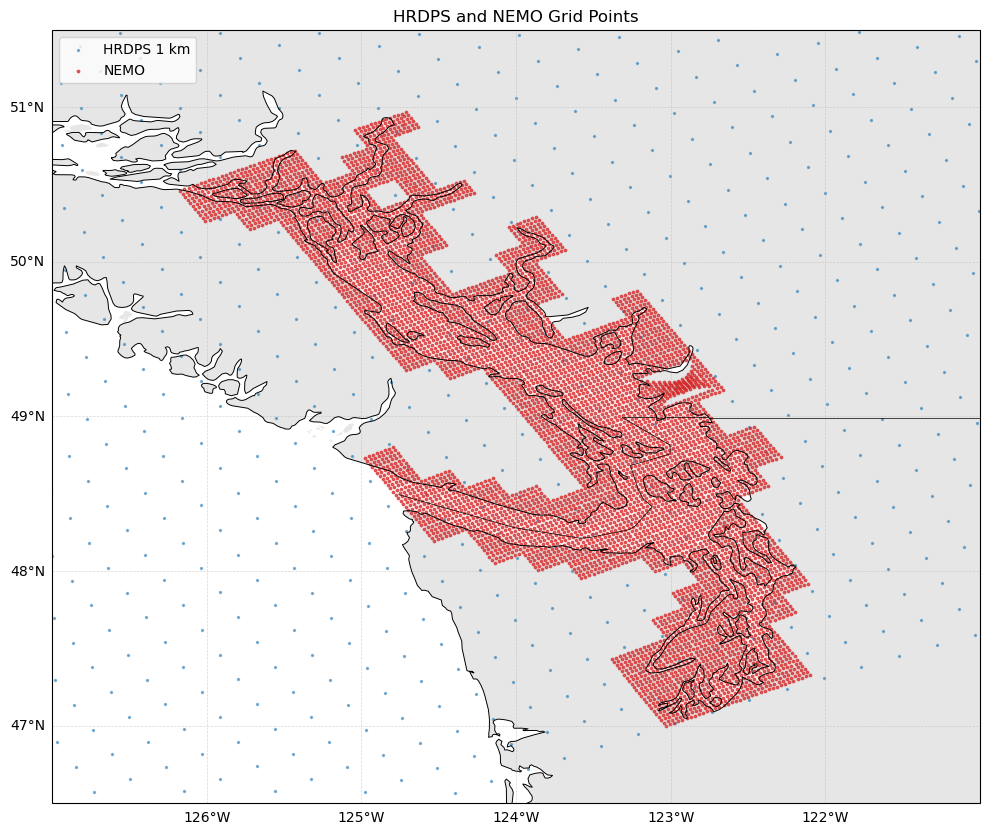

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# 1. Paths
# ============================================================
path_HRDPS = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Data_Conversion/Data_HRDPS_1km_conversion/'
    'HRDPS_1km_y2023m03d01.nc'
)

path_NEMO = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

# ============================================================
# 2. Open datasets
# ============================================================
ds_HRDPS = xr.open_dataset(path_HRDPS)
ds_NEMO = xr.open_dataset(path_NEMO)

# 经纬度
lon_HRDPS = ds_HRDPS['nav_lon'].values
lat_HRDPS = ds_HRDPS['nav_lat'].values

lon_NEMO = ds_NEMO['nav_lon'].values
lat_NEMO = ds_NEMO['nav_lat'].values

print('HRDPS grid shape:', lon_HRDPS.shape)
print('NEMO  grid shape:', lon_NEMO.shape)

print(
    'HRDPS lon/lat range:',
    np.nanmin(lon_HRDPS), np.nanmax(lon_HRDPS),
    np.nanmin(lat_HRDPS), np.nanmax(lat_HRDPS)
)

print(
    'NEMO lon/lat range:',
    np.nanmin(lon_NEMO), np.nanmax(lon_NEMO),
    np.nanmin(lat_NEMO), np.nanmax(lat_NEMO)
)

# ============================================================
# 3. Subsample grids
# ============================================================
# HRDPS 是 1 km 网格，非常密，抽稀多一点
skip_HRDPS = 20

# NEMO 网格相对小一些
skip_NEMO = 5

lon_HRDPS_sub = lon_HRDPS[::skip_HRDPS, ::skip_HRDPS]
lat_HRDPS_sub = lat_HRDPS[::skip_HRDPS, ::skip_HRDPS]

lon_NEMO_sub = lon_NEMO[::skip_NEMO, ::skip_NEMO]
lat_NEMO_sub = lat_NEMO[::skip_NEMO, ::skip_NEMO]

# ============================================================
# 4. Plot
# ============================================================
fig = plt.figure(figsize=(10, 10))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

# coastline / land
ax.add_feature(
    cfeature.LAND,
    facecolor='0.9',
    zorder=0
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.7,
    zorder=3
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.5,
    zorder=3
)

# HRDPS grid points
ax.scatter(
    lon_HRDPS_sub,
    lat_HRDPS_sub,
    s=2,
    color='tab:blue',
    alpha=0.5,
    label='HRDPS 1 km',
    transform=ccrs.PlateCarree(),
    zorder=1
)

# NEMO grid points
ax.scatter(
    lon_NEMO_sub,
    lat_NEMO_sub,
    s=3,
    color='tab:red',
    alpha=0.7,
    label='NEMO',
    transform=ccrs.PlateCarree(),
    zorder=2
)

# ============================================================
# 5. Zoom to NEMO / Salish Sea region
# ============================================================
# 根据 NEMO 经纬度自动确定显示范围
margin = 0.3

lon_min = np.nanmin(lon_NEMO)
lon_max = np.nanmax(lon_NEMO)
lat_min = np.nanmin(lat_NEMO)
lat_max = np.nanmax(lat_NEMO)

# ax.set_extent(
#     [
#         lon_min - margin,
#         lon_max + margin,
#         lat_min - margin,
#         lat_max + margin
#     ],
#     crs=ccrs.PlateCarree()
# )

ax.set_extent([-127.0, -121.0, 46.5, 51.5])

# grid lines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    alpha=0.5,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False

ax.legend(loc='upper left')

ax.set_title(
    'HRDPS and NEMO Grid Points'
)

plt.tight_layout()
plt.show()

# ============================================================
# 6. Close files
# ============================================================
ds_HRDPS.close()
ds_NEMO.close()

### Is the Southest point in NEMO within HRDPS range?

Number of NEMO southern boundary points: 398
Southernmost NEMO latitude: 46.996746

NEMO southern boundary inside HRDPS:
    398 / 398 points inside
    100.00% inside

>>> YES: 整个 NEMO 南边界都在 HRDPS 范围内


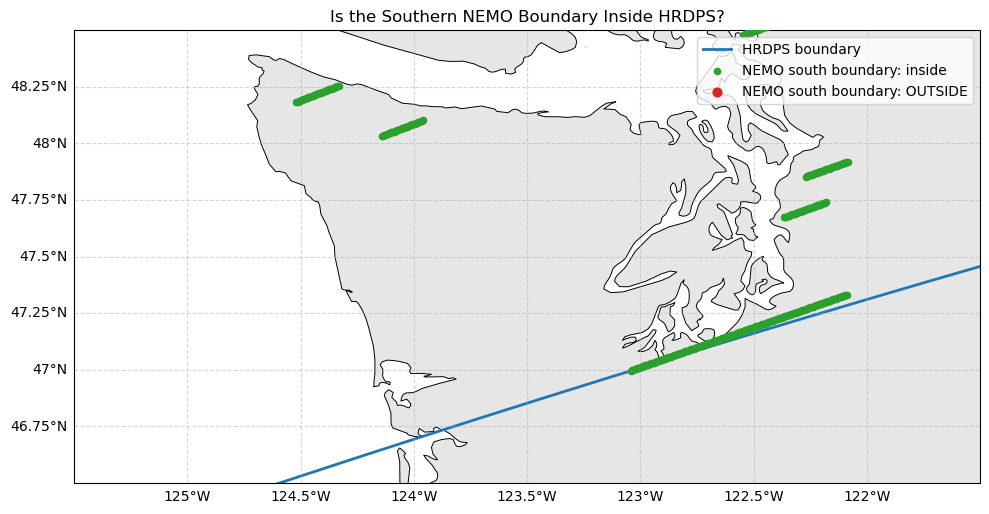

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# 1. HRDPS longitude 转成 -180 ~ 180
# ============================================================
lon_HRDPS_plot = ((lon_HRDPS + 180) % 360) - 180
lat_HRDPS_plot = lat_HRDPS.copy()


# ============================================================
# 2. NEMO 无效点去掉
# ============================================================
valid_NEMO = (
    np.isfinite(lon_NEMO) &
    np.isfinite(lat_NEMO) &
    (lon_NEMO != -1) &
    (lat_NEMO != -1)
)


# ============================================================
# 3. 找 NEMO 最南边的有效网格点
# ============================================================
#
# 这里不是简单找全场纬度最小的一个点，
# 而是对每个 x-column 找最南边的有效点，
# 这样得到整个 NEMO 南边界。
#

south_lons = []
south_lats = []

ny, nx = lon_NEMO.shape

for i in range(nx):

    valid_j = np.where(valid_NEMO[:, i])[0]

    if len(valid_j) == 0:
        continue

    # 这个 column 中纬度最低的点
    j = valid_j[np.argmin(lat_NEMO[valid_j, i])]

    south_lons.append(lon_NEMO[j, i])
    south_lats.append(lat_NEMO[j, i])

south_lons = np.asarray(south_lons)
south_lats = np.asarray(south_lats)

print('Number of NEMO southern boundary points:', len(south_lons))
print('Southernmost NEMO latitude:', np.nanmin(south_lats))


# ============================================================
# 4. 构造 HRDPS 外边界 polygon
# ============================================================
#
# 顺序：
# top    : left -> right
# right  : top -> bottom
# bottom : right -> left
# left   : bottom -> top
#

top_lon = lon_HRDPS_plot[0, :]
top_lat = lat_HRDPS_plot[0, :]

right_lon = lon_HRDPS_plot[1:, -1]
right_lat = lat_HRDPS_plot[1:, -1]

bottom_lon = lon_HRDPS_plot[-1, -2::-1]
bottom_lat = lat_HRDPS_plot[-1, -2::-1]

left_lon = lon_HRDPS_plot[-2:0:-1, 0]
left_lat = lat_HRDPS_plot[-2:0:-1, 0]

boundary_lon = np.concatenate([
    top_lon,
    right_lon,
    bottom_lon,
    left_lon
])

boundary_lat = np.concatenate([
    top_lat,
    right_lat,
    bottom_lat,
    left_lat
])

boundary_points = np.column_stack([
    boundary_lon,
    boundary_lat
])

hrdps_polygon = Path(boundary_points)


# ============================================================
# 5. 判断 NEMO 南边界是否在 HRDPS 内部
# ============================================================
nemo_south_points = np.column_stack([
    south_lons,
    south_lats
])

inside = hrdps_polygon.contains_points(nemo_south_points)

print()
print('NEMO southern boundary inside HRDPS:')
print(f'    {inside.sum()} / {len(inside)} points inside')

print(f'    {100 * inside.mean():.2f}% inside')

if np.all(inside):
    print('\n>>> YES: 整个 NEMO 南边界都在 HRDPS 范围内')
else:
    print('\n>>> NO: 有 NEMO 南边界点超出 HRDPS 范围')
    print('Number outside:', (~inside).sum())

    print('\nOutside points:')
    for lon, lat in zip(south_lons[~inside], south_lats[~inside]):
        print(f'lon = {lon:.5f}, lat = {lat:.5f}')


# ============================================================
# 6. 画图检查
# ============================================================
fig = plt.figure(figsize=(10, 10))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

ax.add_feature(
    cfeature.LAND,
    facecolor='0.9'
)

ax.coastlines(
    linewidth=0.7
)


# HRDPS 外边界
ax.plot(
    np.append(boundary_lon, boundary_lon[0]),
    np.append(boundary_lat, boundary_lat[0]),
    color='tab:blue',
    linewidth=2,
    label='HRDPS boundary',
    transform=ccrs.PlateCarree()
)


# NEMO 南边界：在 HRDPS 内部的点
ax.scatter(
    south_lons[inside],
    south_lats[inside],
    s=20,
    color='tab:green',
    label='NEMO south boundary: inside',
    transform=ccrs.PlateCarree(),
    zorder=5
)


# NEMO 南边界：超出去的点
ax.scatter(
    south_lons[~inside],
    south_lats[~inside],
    s=40,
    color='tab:red',
    label='NEMO south boundary: OUTSIDE',
    transform=ccrs.PlateCarree(),
    zorder=6
)


# 专门 zoom 到南边
ax.set_extent(
    [-125.5, -121.5, 46.5, 48.5],
    crs=ccrs.PlateCarree()
)

gl = ax.gridlines(
    draw_labels=True,
    linestyle='--',
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

ax.legend()

ax.set_title(
    'Is the Southern NEMO Boundary Inside HRDPS?'
)

plt.tight_layout()
plt.show()

## Try bathy vs HRDPS

In [9]:
import xarray as xr

path_bathy='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_weights/HRDPS_1km_Weights/bathy_meter.nc'

ds_bathy=xr.load_dataset(path_bathy)

print(ds_bathy)

<xarray.Dataset> Size: 4MB
Dimensions:     (y: 898, x: 398)
Dimensions without coordinates: y, x
Data variables:
    nav_lon     (y, x) float32 1MB -123.4 -123.4 -123.4 ... -124.4 -124.3 -124.3
    nav_lat     (y, x) float32 1MB 46.86 46.86 46.86 46.87 ... 51.1 51.1 51.1
    Bathymetry  (y, x) float32 1MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    CDI:          Climate Data Interface version 1.5.9 (http://code.zmaw.de/p...
    Conventions:  CF-1.4
    history:      Fri Jul 19 16:03:29 2013: cdo setrtoc,0,4,4 ../1_Seagrid/1_...
    CDO:          Climate Data Operators version 1.5.9rc3 (http://code.zmaw.d...


HRDPS grid shape: (1180, 1330)
NEMO  grid shape: (898, 398)
HRDPS lon/lat range: 225.370032 250.467424 45.932892 60.295024
NEMO lon/lat range: -126.40029 -121.31835 46.859665 51.1048


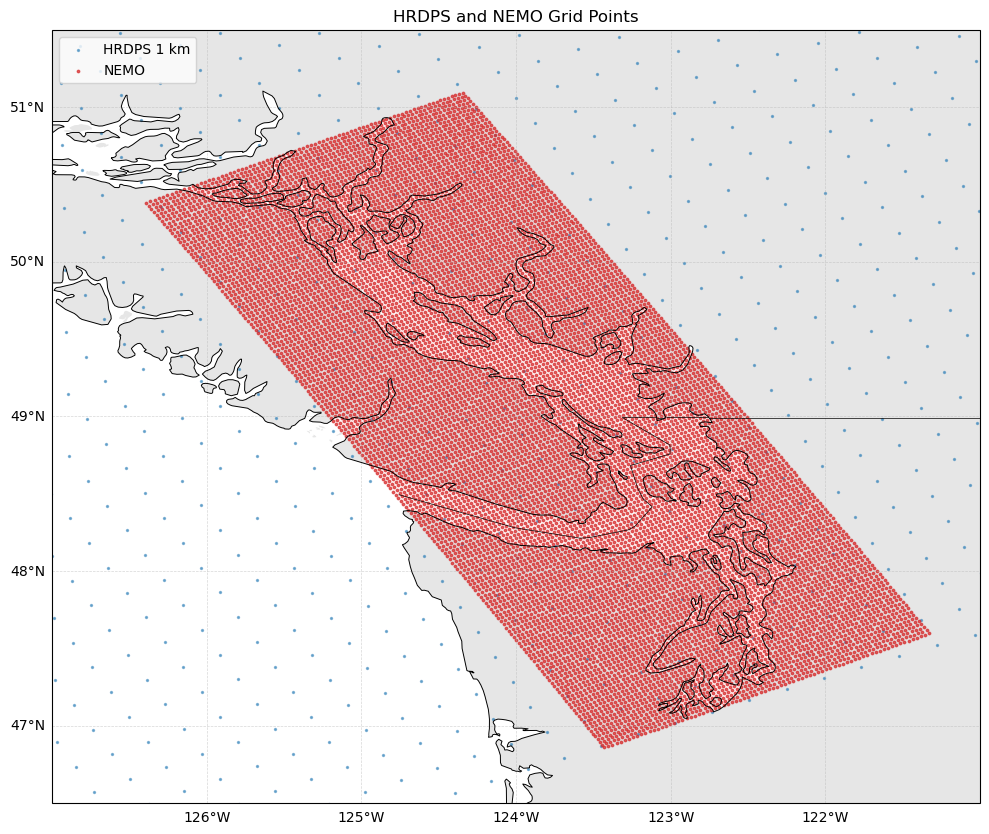

In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# 1. Paths
# ============================================================
path_HRDPS = (
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/'
    'Data_Conversion/Data_HRDPS_1km_conversion/'
    'HRDPS_1km_y2023m03d01.nc'
)

path_bathy = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_weights/HRDPS_1km_Weights/bathy_meter.nc'

# ============================================================
# 2. Open datasets
# ============================================================
ds_HRDPS = xr.open_dataset(path_HRDPS)
ds_NEMO = xr.open_dataset(path_bathy)

# 经纬度
lon_HRDPS = ds_HRDPS['nav_lon'].values
lat_HRDPS = ds_HRDPS['nav_lat'].values

lon_NEMO = ds_NEMO['nav_lon'].values
lat_NEMO = ds_NEMO['nav_lat'].values

print('HRDPS grid shape:', lon_HRDPS.shape)
print('NEMO  grid shape:', lon_NEMO.shape)

print(
    'HRDPS lon/lat range:',
    np.nanmin(lon_HRDPS), np.nanmax(lon_HRDPS),
    np.nanmin(lat_HRDPS), np.nanmax(lat_HRDPS)
)

print(
    'NEMO lon/lat range:',
    np.nanmin(lon_NEMO), np.nanmax(lon_NEMO),
    np.nanmin(lat_NEMO), np.nanmax(lat_NEMO)
)

# ============================================================
# 3. Subsample grids
# ============================================================
# HRDPS 是 1 km 网格，非常密，抽稀多一点
skip_HRDPS = 20

# NEMO 网格相对小一些
skip_NEMO = 5

lon_HRDPS_sub = lon_HRDPS[::skip_HRDPS, ::skip_HRDPS]
lat_HRDPS_sub = lat_HRDPS[::skip_HRDPS, ::skip_HRDPS]

lon_NEMO_sub = lon_NEMO[::skip_NEMO, ::skip_NEMO]
lat_NEMO_sub = lat_NEMO[::skip_NEMO, ::skip_NEMO]

# ============================================================
# 4. Plot
# ============================================================
fig = plt.figure(figsize=(10, 10))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

# coastline / land
ax.add_feature(
    cfeature.LAND,
    facecolor='0.9',
    zorder=0
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.7,
    zorder=3
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.5,
    zorder=3
)

# HRDPS grid points
ax.scatter(
    lon_HRDPS_sub,
    lat_HRDPS_sub,
    s=2,
    color='tab:blue',
    alpha=0.5,
    label='HRDPS 1 km',
    transform=ccrs.PlateCarree(),
    zorder=1
)

# NEMO grid points
ax.scatter(
    lon_NEMO_sub,
    lat_NEMO_sub,
    s=3,
    color='tab:red',
    alpha=0.7,
    label='NEMO',
    transform=ccrs.PlateCarree(),
    zorder=2
)

# ============================================================
# 5. Zoom to NEMO / Salish Sea region
# ============================================================
# 根据 NEMO 经纬度自动确定显示范围
margin = 0.3

lon_min = np.nanmin(lon_NEMO)
lon_max = np.nanmax(lon_NEMO)
lat_min = np.nanmin(lat_NEMO)
lat_max = np.nanmax(lat_NEMO)

# ax.set_extent(
#     [
#         lon_min - margin,
#         lon_max + margin,
#         lat_min - margin,
#         lat_max + margin
#     ],
#     crs=ccrs.PlateCarree()
# )

ax.set_extent([-127.0, -121.0, 46.5, 51.5])

# grid lines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    alpha=0.5,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False

ax.legend(loc='upper left')

ax.set_title(
    'HRDPS and NEMO Grid Points'
)

plt.tight_layout()
plt.show()

# ============================================================
# 6. Close files
# ============================================================
ds_HRDPS.close()
ds_NEMO.close()

Number of NEMO southern boundary points: 398
Southernmost NEMO latitude: 46.859665

NEMO southern boundary inside HRDPS:
    328 / 398 points inside
    82.41% inside

>>> NO: 有 NEMO 南边界点超出 HRDPS 范围
Number outside: 70


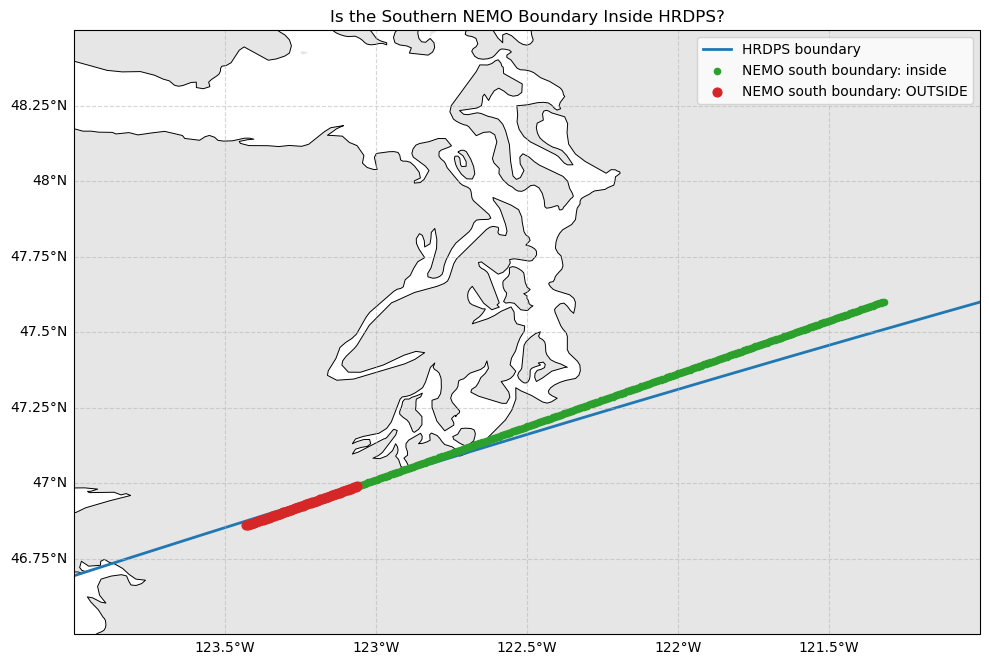

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# 1. HRDPS longitude 转成 -180 ~ 180
# ============================================================
lon_HRDPS_plot = ((lon_HRDPS + 180) % 360) - 180
lat_HRDPS_plot = lat_HRDPS.copy()


# ============================================================
# 2. NEMO 无效点去掉
# ============================================================
valid_NEMO = (
    np.isfinite(lon_NEMO) &
    np.isfinite(lat_NEMO) &
    (lon_NEMO != -1) &
    (lat_NEMO != -1)
)


# ============================================================
# 3. 找 NEMO 最南边的有效网格点
# ============================================================
#
# 这里不是简单找全场纬度最小的一个点，
# 而是对每个 x-column 找最南边的有效点，
# 这样得到整个 NEMO 南边界。
#

south_lons = []
south_lats = []

ny, nx = lon_NEMO.shape

for i in range(nx):

    valid_j = np.where(valid_NEMO[:, i])[0]

    if len(valid_j) == 0:
        continue

    # 这个 column 中纬度最低的点
    j = valid_j[np.argmin(lat_NEMO[valid_j, i])]

    south_lons.append(lon_NEMO[j, i])
    south_lats.append(lat_NEMO[j, i])

south_lons = np.asarray(south_lons)
south_lats = np.asarray(south_lats)

print('Number of NEMO southern boundary points:', len(south_lons))
print('Southernmost NEMO latitude:', np.nanmin(south_lats))


# ============================================================
# 4. 构造 HRDPS 外边界 polygon
# ============================================================
#
# 顺序：
# top    : left -> right
# right  : top -> bottom
# bottom : right -> left
# left   : bottom -> top
#

top_lon = lon_HRDPS_plot[0, :]
top_lat = lat_HRDPS_plot[0, :]

right_lon = lon_HRDPS_plot[1:, -1]
right_lat = lat_HRDPS_plot[1:, -1]

bottom_lon = lon_HRDPS_plot[-1, -2::-1]
bottom_lat = lat_HRDPS_plot[-1, -2::-1]

left_lon = lon_HRDPS_plot[-2:0:-1, 0]
left_lat = lat_HRDPS_plot[-2:0:-1, 0]

boundary_lon = np.concatenate([
    top_lon,
    right_lon,
    bottom_lon,
    left_lon
])

boundary_lat = np.concatenate([
    top_lat,
    right_lat,
    bottom_lat,
    left_lat
])

boundary_points = np.column_stack([
    boundary_lon,
    boundary_lat
])

hrdps_polygon = Path(boundary_points)


# ============================================================
# 5. 判断 NEMO 南边界是否在 HRDPS 内部
# ============================================================
nemo_south_points = np.column_stack([
    south_lons,
    south_lats
])

inside = hrdps_polygon.contains_points(nemo_south_points)

print()
print('NEMO southern boundary inside HRDPS:')
print(f'    {inside.sum()} / {len(inside)} points inside')

print(f'    {100 * inside.mean():.2f}% inside')

if np.all(inside):
    print('\n>>> YES: 整个 NEMO 南边界都在 HRDPS 范围内')
else:
    print('\n>>> NO: 有 NEMO 南边界点超出 HRDPS 范围')
    print('Number outside:', (~inside).sum())

    # print('\nOutside points:')
    # for lon, lat in zip(south_lons[~inside], south_lats[~inside]):
    #     print(f'lon = {lon:.5f}, lat = {lat:.5f}')


# ============================================================
# 6. 画图检查
# ============================================================
fig = plt.figure(figsize=(10, 10))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

ax.add_feature(
    cfeature.LAND,
    facecolor='0.9'
)

ax.coastlines(
    linewidth=0.7
)


# HRDPS 外边界
ax.plot(
    np.append(boundary_lon, boundary_lon[0]),
    np.append(boundary_lat, boundary_lat[0]),
    color='tab:blue',
    linewidth=2,
    label='HRDPS boundary',
    transform=ccrs.PlateCarree()
)


# NEMO 南边界：在 HRDPS 内部的点
ax.scatter(
    south_lons[inside],
    south_lats[inside],
    s=20,
    color='tab:green',
    label='NEMO south boundary: inside',
    transform=ccrs.PlateCarree(),
    zorder=5
)


# NEMO 南边界：超出去的点
ax.scatter(
    south_lons[~inside],
    south_lats[~inside],
    s=40,
    color='tab:red',
    label='NEMO south boundary: OUTSIDE',
    transform=ccrs.PlateCarree(),
    zorder=6
)


# 专门 zoom 到南边
ax.set_extent(
    [-124, -121, 46.5, 48.5],
    crs=ccrs.PlateCarree()
)

gl = ax.gridlines(
    draw_labels=True,
    linestyle='--',
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

ax.legend()

ax.set_title(
    'Is the Southern NEMO Boundary Inside HRDPS?'
)

plt.tight_layout()
plt.show()